# Examining Local Comparison Results

In [55]:
import numpy as np
import matplotlib.pyplot as plt

In [56]:
slug = "bike_sharing_K30_M10_KF5_REP1"
slug_2 = "bike_sharing_K50_M250_KF5_REP1"
feature_names = ["quarter", "month", "hour", "holiday", "weekday", "workingday", "weather_situation", "atemp", "hum", "windspeed"]
explanations_file = f"figures/{slug}/real_data_explanations.npz"
explanations_file_2 = f"figures/{slug_2}/real_data_explanations.npz"
data = np.load(explanations_file)
data_2 = np.load(explanations_file_2)
shap_explanations = data['shap']
ale_explanations = data['ale']
shap_explanations_2 = data_2['shap']
ale_explanations_2 = data_2['ale']
# dimensions: (k_folds, index, feature)

In [57]:
def plot_histogram_by_feature(data, save_path=None):
    # create one figure with subplots for each feature
    plt.figure(figsize=(15, 10))
    for feature_idx in range(data.shape[2]):
        # get standard deviation across folds
        x = data[:, :, feature_idx].std(axis=0)
        plt.subplot(4, 4, feature_idx + 1)
        plt.hist(x, bins=100, edgecolor='black')
        plt.xlabel("Standard Deviation (each observation)")
        plt.ylabel("Frequency")
        plt.title(f"Feature {feature_names[feature_idx]}")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
    plt.show()

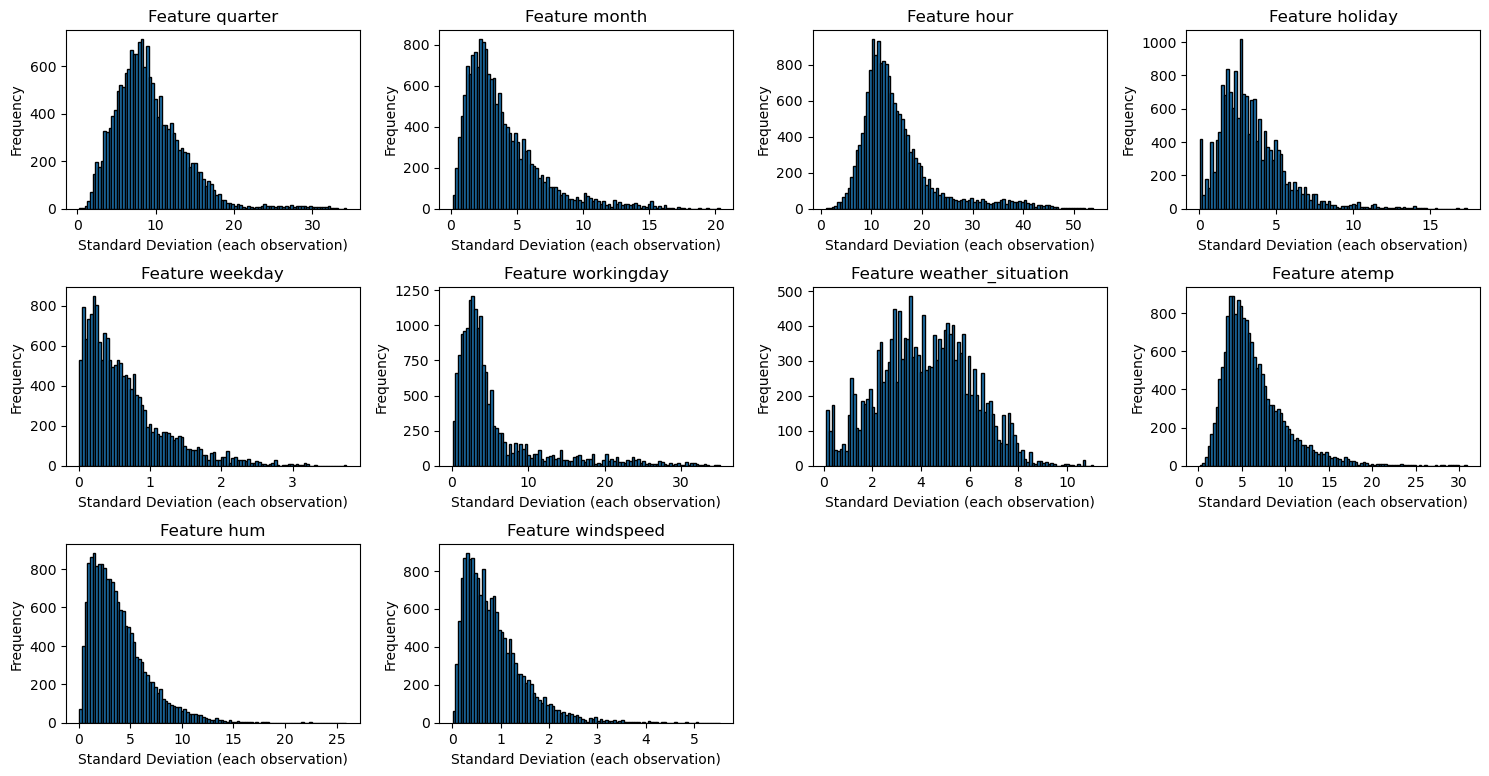

In [58]:
# plot histogram of ale explanation std devs for each feature
plot_histogram_by_feature(ale_explanations, save_path=f"figures/{slug}/ale_std_histograms.png")

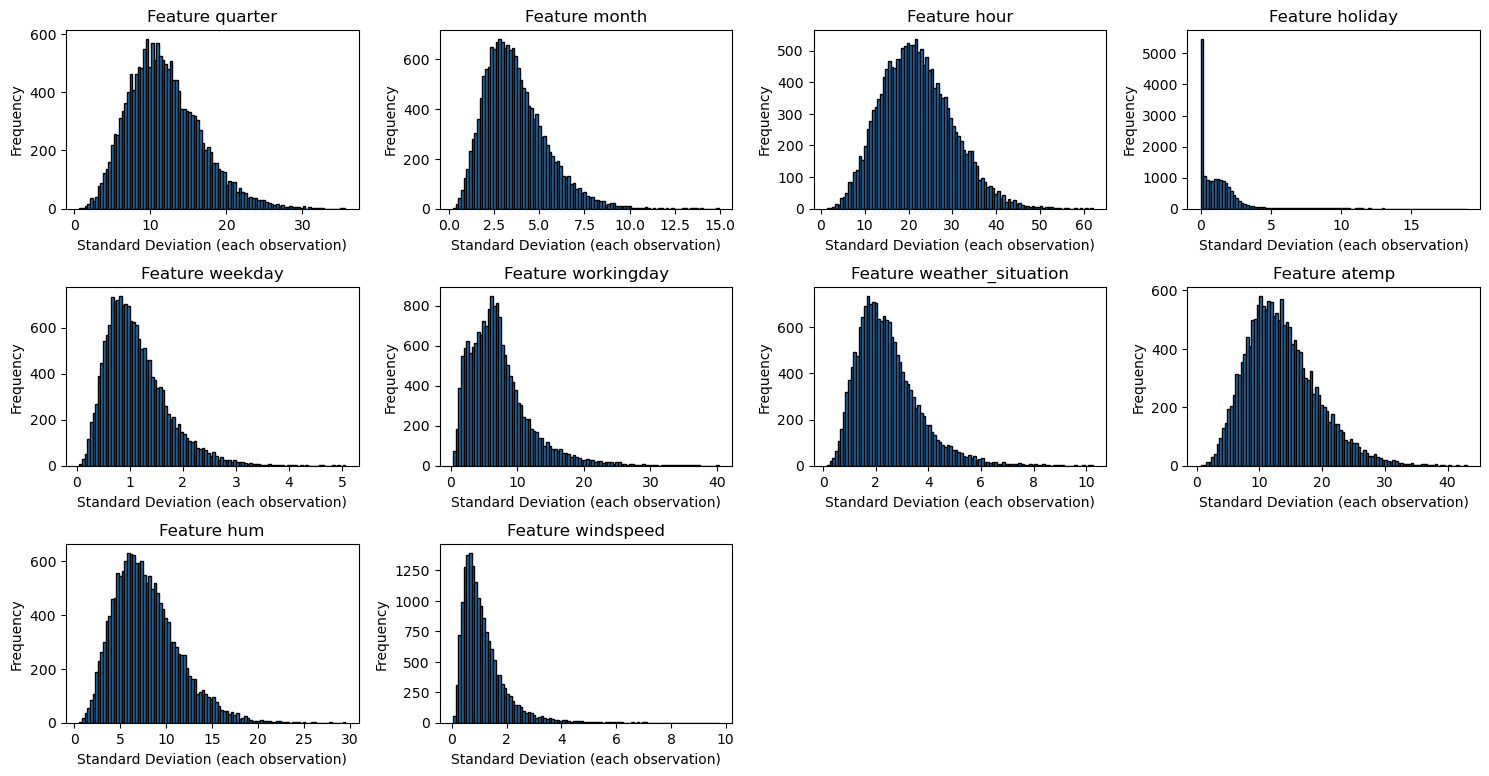

In [59]:
plot_histogram_by_feature(shap_explanations, save_path=f"figures/{slug}/shap_std_histograms.png")

In [60]:
def plot_global_std_barplot(data, save_path=None):
    # bar plot of standard deviation of global explanations across observations
    means = data.mean(axis=1)  # mean across observations
    stds = means.std(axis=0)  # standard deviation across folds
    plt.figure(figsize=(12, 4))
    plt.bar(feature_names, stds)
    plt.xlabel("Feature")
    plt.ylabel("Standard Deviation of Global Explanation")
    plt.title("Standard Deviation of Global Explanations")
    if save_path is not None:
        plt.savefig(save_path)
    plt.show()

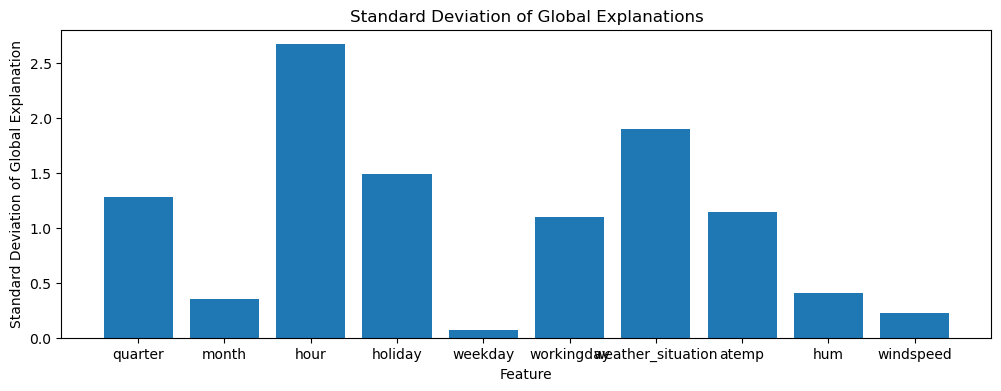

In [61]:
plot_global_std_barplot(ale_explanations, save_path=f"figures/{slug}/ale_global_std_histogram.png")

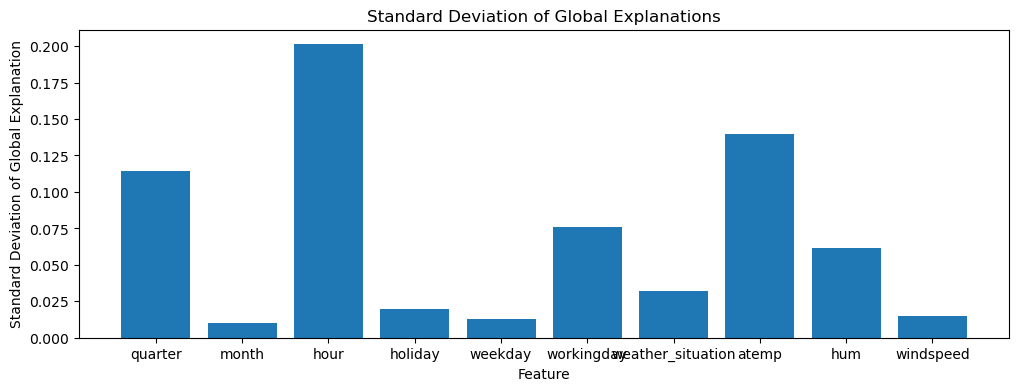

In [62]:
plot_global_std_barplot(shap_explanations, save_path=f"figures/{slug}/shap_global_std_histogram.png")

In [63]:
def plot_mean_std_barplot(data, save_path=None):
    # get standard deviation across folds
    x = data.std(axis=0)
    # take mean across observations
    mean_stds = x.mean(axis=0)
    plt.figure(figsize=(12, 4))
    plt.bar(feature_names, mean_stds)
    plt.xlabel("Feature")
    plt.ylabel("Mean Standard Deviation of Explanation")
    plt.title("Mean Standard Deviation of Explanations")
    if save_path is not None:
        plt.savefig(save_path)
    plt.show()

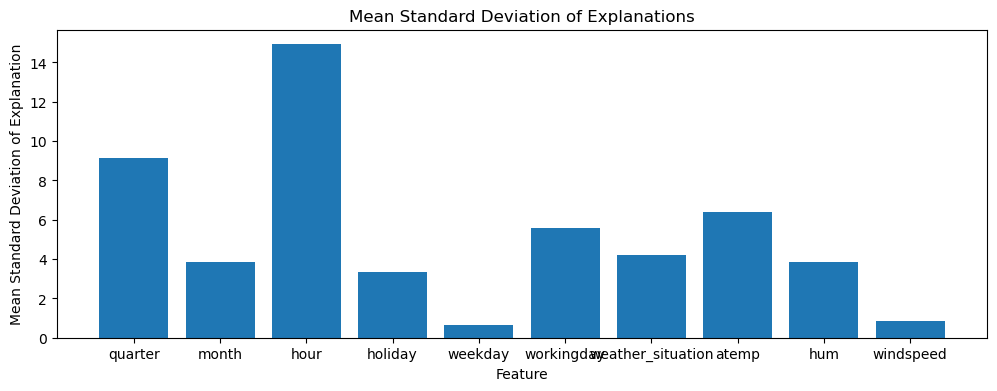

In [64]:
plot_mean_std_barplot(ale_explanations, save_path=f"figures/{slug}/ale_mean_std_histogram.png")

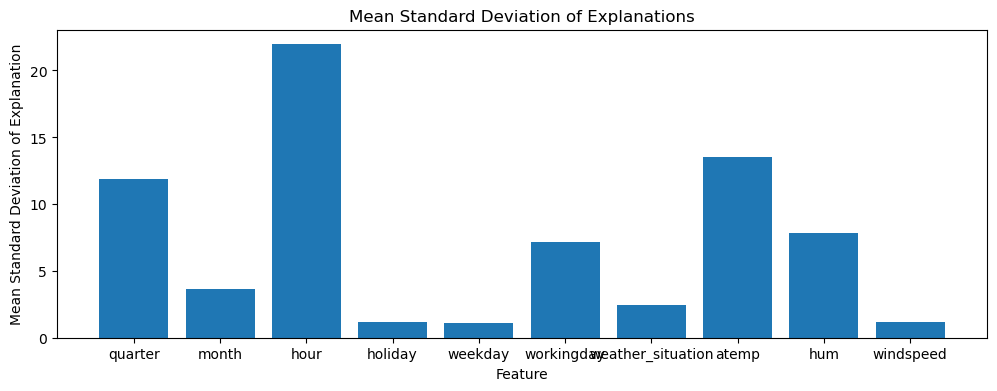

In [65]:
plot_mean_std_barplot(shap_explanations, save_path=f"figures/{slug}/shap_mean_std_histogram.png")